In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.patches import Circle
plt.style.use(['science', 'ieee'])

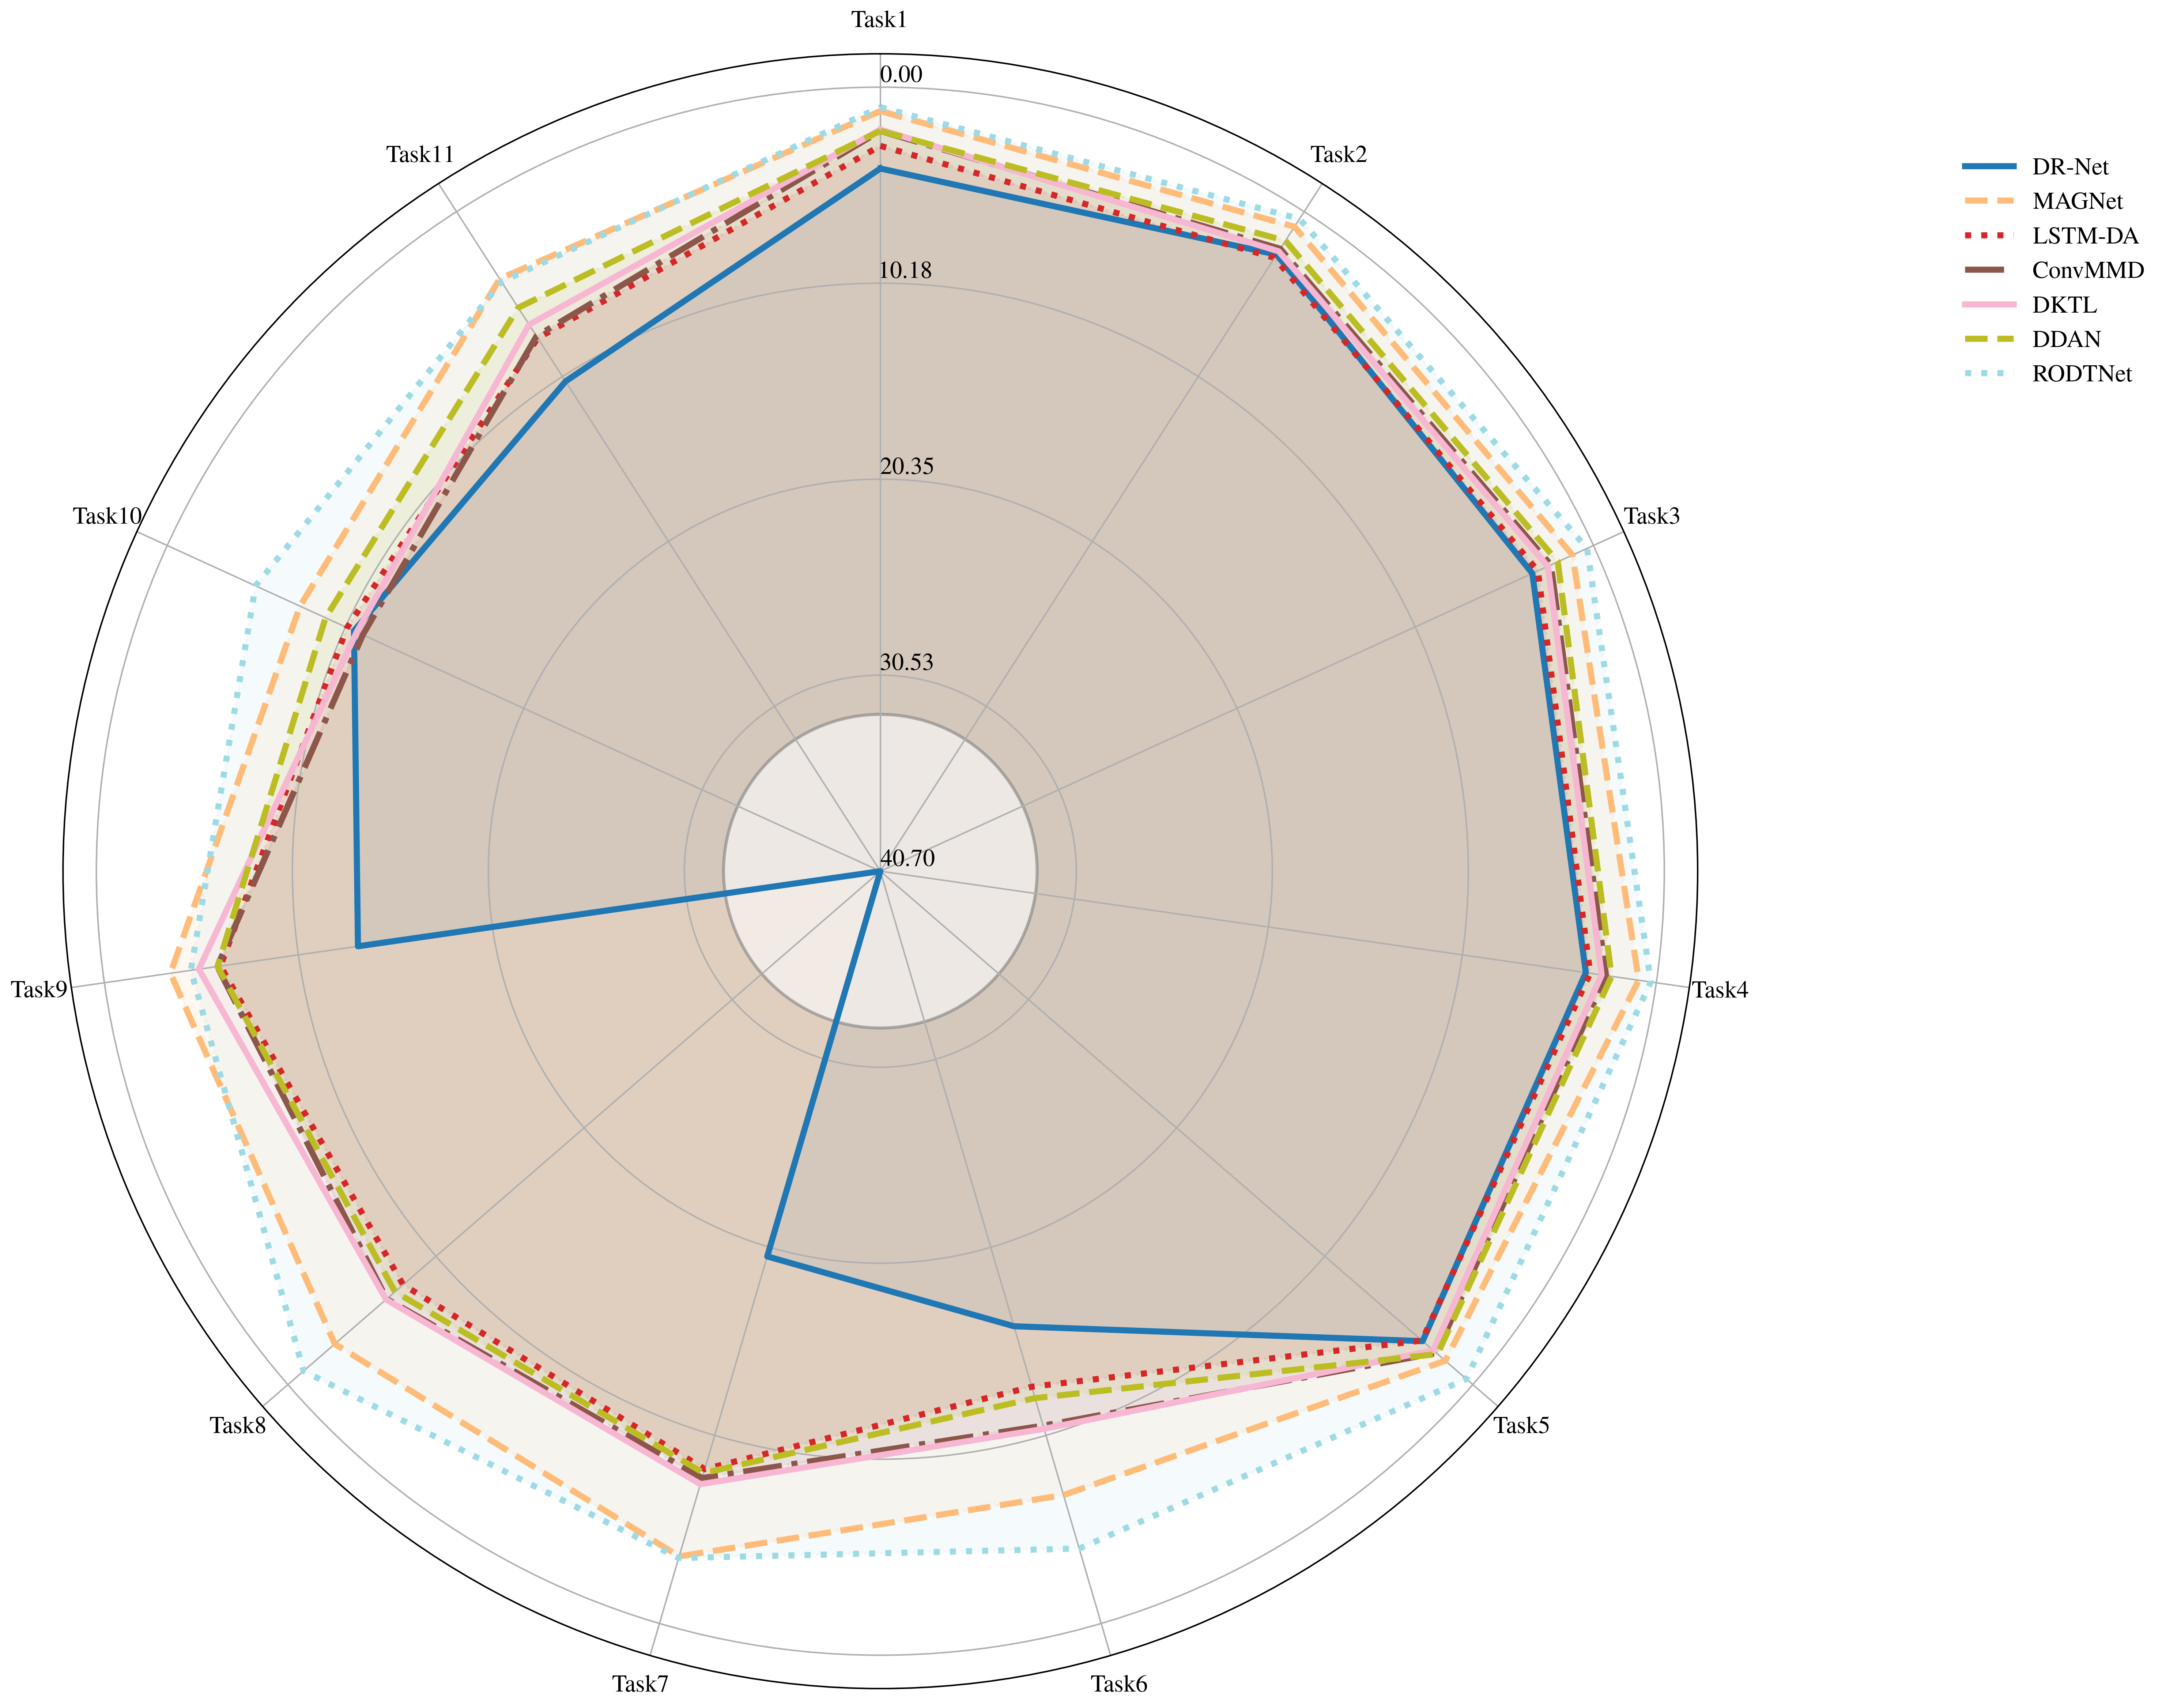

In [9]:
# 读取CSV文件
df = pd.read_csv("../../data/soh/results.csv", index_col=0)  # 假设第一列为模型名称

# 数据预处理
labels = df.columns.tolist()
num_vars = len(labels)

# 反转MAE值（越小越好 -> 越大越好）
max_mae = df.values.max()
df_normalized = max_mae - df

# 设置雷达图参数
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 创建画布
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

# 绘制每个模型的雷达图
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))
for idx, (model, row) in enumerate(df_normalized.iterrows()):
    values = row.values.tolist()
    values += values[:1]  # 闭合数据
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=model)
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

# 设置坐标轴
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)

# 自定义刻度标签
yticks = np.linspace(0, max_mae, 5)
ytick_labels = [f"{max_mae - y:.2f}" for y in yticks]
plt.yticks(yticks, ytick_labels)

# 添加标签和标题
plt.xticks(angles[:-1], labels)
# plt.title("Model Performance Comparison (Lower MAE is Better)", pad=20)

# 添加中心参考圆
center_circle = Circle((0,0), 0.2*max_mae, transform=ax.transData._b, 
                      facecolor='white', edgecolor='gray', alpha=0.6)
ax.add_artist(center_circle)

# 添加图例
plt.legend(bbox_to_anchor=(1.15, 0.95), loc='upper left')

# 调整布局
plt.tight_layout()
# plt.show()
plt.savefig('soh.png')